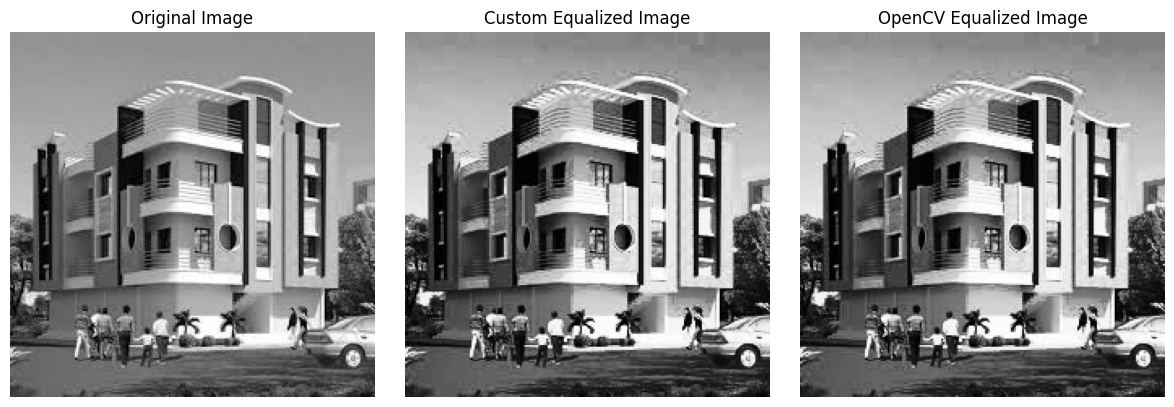

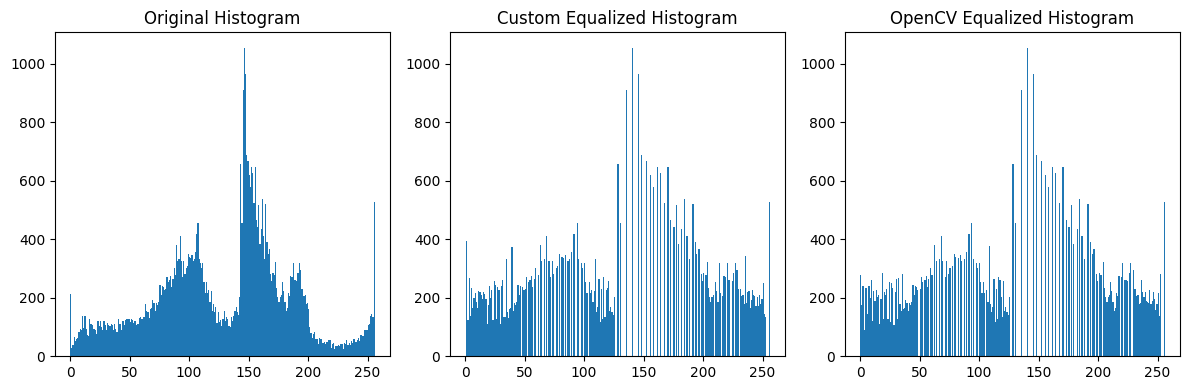

In [ ]:
# ---------------------------------------------------------
# Import Required Libraries
# ---------------------------------------------------------
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Custom Histogram Equalization Function
# ---------------------------------------------------------
def equalize_hist(image, L=256):
    """
    Perform histogram equalization manually.

    Parameters:
    image : Grayscale image (2D numpy array)
    L : Number of intensity levels (default 256)

    Returns:
    equalized_image : Histogram equalized image
    """

    # Step 1: Find unique intensity values and their counts
    intensity_levels, counts = np.unique(image, return_counts=True)

    # Step 2: Calculate total number of pixels
    total_pixels = image.size

    # Step 3: Calculate PDF (Probability Distribution Function)
    pdf = counts / total_pixels

    # Step 4: Calculate CDF (Cumulative Distribution Function)
    cdf = np.cumsum(pdf)

    # Step 5: Create transformation function
    transform = np.floor((L - 1) * cdf).astype(np.uint8)

    # Step 6: Create mapping dictionary
    mapping = dict(zip(intensity_levels, transform))

    # Step 7: Apply mapping to image
    equalized_image = np.vectorize(mapping.get)(image)

    return equalized_image.astype(np.uint8)


# ---------------------------------------------------------
# Main Execution
# ---------------------------------------------------------
if __name__ == "__main__":

    # Read image in grayscale mode
    image = cv2.imread("building.jpg", cv2.IMREAD_GRAYSCALE)

    if image is None:
        print("Error: Image not found. Check the file path.")
        exit()

    # Apply custom histogram equalization
    custom_image = equalize_hist(image)

    # Apply OpenCV histogram equalization
    opencv_image = cv2.equalizeHist(image)

    # -----------------------------------------------------
    # Display Images
    # -----------------------------------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(custom_image, cmap='gray')
    plt.title("Custom Equalized Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(opencv_image, cmap='gray')
    plt.title("OpenCV Equalized Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Display Histograms
    # -----------------------------------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.hist(image.ravel(), bins=256, range=[0, 256])
    plt.title("Original Histogram")

    plt.subplot(1, 3, 2)
    plt.hist(custom_image.ravel(), bins=256, range=[0, 256])
    plt.title("Custom Equalized Histogram")

    plt.subplot(1, 3, 3)
    plt.hist(opencv_image.ravel(), bins=256, range=[0, 256])
    plt.title("OpenCV Equalized Histogram")

    plt.tight_layout()
    plt.show()